In [1]:
import os
import numpy as np
import sklearn
import scipy
import pandas as pd
import pprint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42

In [2]:
PathDir = os.getcwd()

In [3]:
normal = pd.read_csv(os.path.join(PathDir,'Data_CSV',
                                  'all_goIDs_plots_and_csv','SIP1_Abgang1MEAS-LLN0$GO$Control_DataSet',
                                  '01-normal-1.csv'))

In [4]:
normal = pd.DataFrame(normal)
normal.head()

,Unnamed: 0,Time,Time_diff,Source,Destination,Protocol,APPID,gocbRef,goID,Length,...,float_value3,float_value4,float_value5,bit-string_0,bit-string_1,bit-string_2,bit-string_3,bit-string_4,bit-string_5,color
0,0,0.000000,NaN,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
1,1,0.320131,0.320131,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
2,2,0.960914,0.640783,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
3,3,2.241260,1.280346,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
4,4,4.241598,2.000338,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green


In [5]:
normal.columns

Index(['Unnamed: 0', 'Time', 'Time_diff', 'Source', 'Destination', 'Protocol',
       'APPID', 'gocbRef', 'goID', 'Length', 'timeAllowedtoLive', 'datSet',
       't', 'unix_timediff', 'stNum', 'sqNum', 'simulation', 'confRev',
       'ndsCom', 'numDatSetEntries', 'attack', 'label_multi', 'float_value0',
       'float_value1', 'float_value2', 'float_value3', 'float_value4',
       'float_value5', 'bit-string_0', 'bit-string_1', 'bit-string_2',
       'bit-string_3', 'bit-string_4', 'bit-string_5', 'color'],
      dtype='object')

In [6]:
# calculate the time difference between consecutive rows
normal['time_diff'] = normal['Time'].diff()

In [7]:
normal.shape

(1255, 36)

In [8]:
normal['datSet'].value_counts()

datSet
SIP1_Abgang1MEAS/LLN0$Meas_SIP1    1255
Name: count, dtype: int64

In [9]:
normal.dtypes

Unnamed: 0             int64
Time                 float64
Time_diff            float64
Source                object
Destination           object
Protocol              object
APPID                  int64
gocbRef               object
goID                  object
Length                 int64
timeAllowedtoLive      int64
datSet                object
t                    float64
unix_timediff        float64
stNum                  int64
sqNum                  int64
simulation              bool
confRev                int64
ndsCom                  bool
numDatSetEntries       int64
attack                 int64
label_multi          float64
float_value0         float64
float_value1         float64
float_value2         float64
float_value3         float64
float_value4         float64
float_value5         float64
bit-string_0         float64
bit-string_1         float64
bit-string_2         float64
bit-string_3         float64
bit-string_4         float64
bit-string_5         float64
color         

In [10]:
normal_new = normal[normal['datSet'] == 'SIP1_Abgang1MEAS/LLN0$Meas_SIP1']

print(normal_new.shape)
normal_new.head()

(1255, 36)


,Unnamed: 0,Time,Time_diff,Source,Destination,Protocol,APPID,gocbRef,goID,Length,...,float_value4,float_value5,bit-string_0,bit-string_1,bit-string_2,bit-string_3,bit-string_4,bit-string_5,color,time_diff
0,0,0.000000,NaN,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,NaN
1,1,0.320131,0.320131,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.320131
2,2,0.960914,0.640783,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.640783
3,3,2.241260,1.280346,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,1.280346
4,4,4.241598,2.000338,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,2.000338


In [11]:
#normal_new['Label'] = 0
normal_new = normal_new.rename(columns={"attack": "Label"})


In [12]:
normal_new.head()

,Unnamed: 0,Time,Time_diff,Source,Destination,Protocol,APPID,gocbRef,goID,Length,...,float_value4,float_value5,bit-string_0,bit-string_1,bit-string_2,bit-string_3,bit-string_4,bit-string_5,color,time_diff
0,0,0.000000,NaN,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,NaN
1,1,0.320131,0.320131,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.320131
2,2,0.960914,0.640783,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.640783
3,3,2.241260,1.280346,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,1.280346
4,4,4.241598,2.000338,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,2.000338


In [13]:
PathDir

'/home/pruthvish/RA/PowerGrid/PowerDuct'

In [14]:
#attack= pd.read_csv(r'C:\Users\USER\Desktop\Power_Grid\Dataset\Power_Duck_extract\Excel_Files\04-insert-fake-open-w-intermediate.csv')
#attack = pd.read_csv(os.path.join(PathDir,'Data','04-insert-fake-open-w-intermediate.csv'))
attack = pd.read_csv(os.path.join(PathDir,'Data_CSV', 'all_goIDs_plots_and_csv',
                                  'SIP1_Abgang1MEAS-LLN0$GO$Control_DataSet',
                                  '07-insert-distort-meas-down-grad.csv'))


attack = pd.DataFrame(attack)
print(attack.shape)
attack.head()

(2380, 35)


,Unnamed: 0,Time,Time_diff,Source,Destination,Protocol,APPID,gocbRef,goID,Length,...,float_value3,float_value4,float_value5,bit-string_0,bit-string_1,bit-string_2,bit-string_3,bit-string_4,bit-string_5,color
0,0,1.359248,NaN,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
1,1,3.298255,1.939007,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
2,2,3.309263,0.011008,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
3,3,3.319262,0.009999,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green
4,4,3.339512,0.020250,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green


In [15]:
# calculate the time difference between consecutive rows
attack['time_diff'] = attack['Time'].diff()
#attack_new = attack[attack['datSet'] == 'SIP1_Abgang1CTRL/LLN0$CB1']
attack_new = attack[attack['datSet'] == 'SIP1_Abgang1MEAS/LLN0$Meas_SIP1']
# df_new['unix_timestamp'] = pd.to_datetime(df_new['t']).astype('int64') 
#attack_new['time_diff'] = attack_new['Time'].diff()
print(attack_new.shape)
attack_new.head()

(2380, 36)


,Unnamed: 0,Time,Time_diff,Source,Destination,Protocol,APPID,gocbRef,goID,Length,...,float_value4,float_value5,bit-string_0,bit-string_1,bit-string_2,bit-string_3,bit-string_4,bit-string_5,color,time_diff
0,0,1.359248,NaN,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,NaN
1,1,3.298255,1.939007,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,1.939007
2,2,3.309263,0.011008,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.011008
3,3,3.319262,0.009999,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.009999
4,4,3.339512,0.020250,SiemensE_0e:84:3b,Iec-Tc57_01:00:00,GOOSE,2,SIP1_Abgang1MEAS/LLN0$GO$Control_DataSet,Abgang1_6md85/MEAS/LLN0/Control_DataSet,237,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,green,0.020250


In [16]:
attack_new.columns

Index(['Unnamed: 0', 'Time', 'Time_diff', 'Source', 'Destination', 'Protocol',
       'APPID', 'gocbRef', 'goID', 'Length', 'timeAllowedtoLive', 'datSet',
       't', 'unix_timediff', 'stNum', 'sqNum', 'simulation', 'confRev',
       'ndsCom', 'numDatSetEntries', 'attack', 'label_multi', 'float_value0',
       'float_value1', 'float_value2', 'float_value3', 'float_value4',
       'float_value5', 'bit-string_0', 'bit-string_1', 'bit-string_2',
       'bit-string_3', 'bit-string_4', 'bit-string_5', 'color', 'time_diff'],
      dtype='object')

In [17]:
#attack_new = attack_new.drop(['simulation','Source','Destination','Protocol','APPID','allData','gocbRef','t','datSet','ndsCom','integer','float value','boolean','bit-string','goID','Data','confRev','timeAllowedtoLive','numDatSetEntries','label_multi'], axis = 1)
attack_new = attack_new.drop(['Unnamed: 0','Source', 'Destination', 'Protocol', 'gocbRef', 'goID', 'datSet', 'color' ], axis = 1)

#print(attack_new.shape)
attack_new.head()

,Time,Time_diff,APPID,Length,timeAllowedtoLive,t,unix_timediff,stNum,sqNum,simulation,...,float_value3,float_value4,float_value5,bit-string_0,bit-string_1,bit-string_2,bit-string_3,bit-string_4,bit-string_5,time_diff
0,1.359248,NaN,2,237,3000,1.659709e+09,NaN,83793,13,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,3.298255,1.939007,2,237,3000,1.659709e+09,12.5,83794,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.939007
2,3.309263,0.011008,2,237,3000,1.659709e+09,0.0,83794,1,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011008
3,3.319262,0.009999,2,237,3000,1.659709e+09,0.0,83794,2,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009999
4,3.339512,0.020250,2,237,3000,1.659709e+09,0.0,83794,3,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020250


In [18]:
attack_new = attack_new.rename(columns={"attack": "Label"})
attack_new.columns

Index(['Time', 'Time_diff', 'APPID', 'Length', 'timeAllowedtoLive', 't',
       'unix_timediff', 'stNum', 'sqNum', 'simulation', 'confRev', 'ndsCom',
       'numDatSetEntries', 'Label', 'label_multi', 'float_value0',
       'float_value1', 'float_value2', 'float_value3', 'float_value4',
       'float_value5', 'bit-string_0', 'bit-string_1', 'bit-string_2',
       'bit-string_3', 'bit-string_4', 'bit-string_5', 'time_diff'],
      dtype='object')

In [19]:
# attack_new = attack_new.rename(columns={"attack": "Label"})
attack_new['Label'].value_counts()

Label
1    1481
0     899
Name: count, dtype: int64

In [20]:
def NormalizeGraphs(AxisList, Axis_Value):

    '''Appoach: Bound from lowest and highest value of individual axis; and Ticks from Highest Range'''
    LimList = np.array([rec.get_xlim() if Axis_Value=='XAxis' else rec.get_ylim() for rec in AxisList])


    Lim_LowerValue = np.amin(np.array(LimList)[:,0]) # Min of first column i.e., Lower Bound
    Lim_UpperValue = np.amax(np.array(LimList)[:,1]) # Min of first column i.e., Upper Bound

    Lim = (Lim_LowerValue, Lim_UpperValue)

    Range = LimList[:,1]-LimList[:,0]
    AxisWithHighestRange = np.argmax(Range)
    
    for index, Axis in enumerate(AxisList):
        if Axis_Value=='XAxis':
            AxisList[index].set_xlim(Lim)
        else:
            AxisList[index].set_ylim(Lim)

    return(AxisList)


def getScatterSubplot_SingleRecord(axis, Record, PlotType, Title, YLabel, XLabel, ColorMarker, TestPlotFlag):
    #axis.plot(np.arange(Record.shape[0]), Record,ColorMarker, label=PlotType)
    ColorMarker_LegitimateData_Flag = False
    ColorMarker_InjectedData_Flag = False

    if TestPlotFlag==True:
        for index, (Record_pt,color) in enumerate(zip(Record,ColorMarker)):
            if color=='kx' and ColorMarker_LegitimateData_Flag == False:
                axis.plot(index,Record_pt,color,label='Normal data')
                ColorMarker_LegitimateData_Flag = True
            elif color=='r^' and ColorMarker_InjectedData_Flag == False:
                axis.plot(index,Record_pt,color,label='Attack Data')
                ColorMarker_InjectedData_Flag = True
            else:
                axis.plot(index,Record_pt,color)
    else:
        axis.plot(np.arange(Record.shape[0]), Record,ColorMarker, label=PlotType)
        
    axis.set_title(Title,fontsize=10)
    axis.set_ylabel(YLabel,fontsize=8)
    axis.set_xlabel(XLabel,fontsize=8)


    axis.legend()
    axis.tick_params(axis='both', which='major', labelsize=8)
    axis.tick_params(axis='both', which='minor', labelsize=8)

    return(axis)

def getDistributionSubplot_SingleRecord(axis_2, Record, PlotType, Title, YLabel, YLabel_2, XLabel):
    
    sns.histplot(Record, ax=axis_2, bins = 20)
    axis_2_2 = axis_2.twinx()
    sns.kdeplot(Record,color='k',ax=axis_2_2, warn_singular=False)
    #axis_2.set_xlim(-1.5,270)
    axis_2.set_title(Title, fontsize=10)
    axis_2.set_ylabel(YLabel, fontsize=8)
    axis_2_2.set_ylabel(YLabel_2, fontsize=8)
    axis_2.set_xlabel(XLabel, fontsize=8)

    axis_2.tick_params(axis='both', which='major', labelsize=8)
    axis_2.tick_params(axis='both', which='minor', labelsize=8)
    axis_2_2.tick_params(axis='both', which='major', labelsize=8)
    axis_2_2.tick_params(axis='both', which='minor', labelsize=8)

    axis_2.legend(labels=['Normal data'])
    axis_2_2.legend([],[], frameon=False)
    
    return(axis_2, axis_2_2)

def getDistributionSubplot_SingleRecord(axis_2, Record, PlotType, Title, YLabel, YLabel_2, XLabel):
    
    sns.histplot(Record, ax=axis_2, bins = 20)
    axis_2_2 = axis_2.twinx()
    sns.kdeplot(Record,color='k',ax=axis_2_2, warn_singular=False)
    #axis_2.set_xlim(-1.5,270)
    axis_2.set_title(Title, fontsize=10)
    axis_2.set_ylabel(YLabel, fontsize=8)
    axis_2_2.set_ylabel(YLabel_2, fontsize=8)
    axis_2.set_xlabel(XLabel, fontsize=8)

    axis_2.tick_params(axis='both', which='major', labelsize=8)
    axis_2.tick_params(axis='both', which='minor', labelsize=8)
    axis_2_2.tick_params(axis='both', which='major', labelsize=8)
    axis_2_2.tick_params(axis='both', which='minor', labelsize=8)

    axis_2.legend(labels=['Attack Data', 'Normal data'])
    axis_2_2.legend([],[], frameon=False)
    
    return(axis_2, axis_2_2)

def BarPlot_WithShift(axis, XValue, XShiftValue, YValue, Label, XLabel, YLabel, Title,Color):
    X_axis = np.arange(len(XValue)) 
    axis.set_xticks(X_axis, XValue) 

    axis.bar(X_axis-XShiftValue, YValue, 0.1, label = Label, edgecolor=Color,fill=False) 
    #axis.bar(X_axis, YValue, 0.3, label = Label, edgecolor=Color,fill=False) 
    
    axis.tick_params(axis='x', labelsize=8)
    axis.set_title(Title,fontsize=10)
    axis.set_ylabel(YLabel,fontsize=8)
    axis.set_xlabel(XLabel,fontsize=8)
    
    return(axis)


def getQuartiles(FeatureColumnValues):
    return(np.asarray([np.nanpercentile(FeatureColumnValues,0), 
                       np.nanpercentile(FeatureColumnValues,25),
                       np.nanpercentile(FeatureColumnValues,50),
                       np.nanpercentile(FeatureColumnValues,75),
                       np.nanpercentile(FeatureColumnValues,100)]))    


# Bins: [Q0,Q1,Q2,Q3,Q4] --> [<Q0,Q0-Q1,Q1-Q2,Q2-Q3,Q3-Q4,>Q4]
def GetDistributionCount(FeatureColumnValue, Bins):
    DistributionArray = np.zeros(Bins.shape[0]+1)
    # For Value less than Q0 (For all cases: attack free and attack cases)
    FeatureColumnValue_ForBin = FeatureColumnValue[Bins[0]>FeatureColumnValue]
    DistributionArray[0] = FeatureColumnValue_ForBin.shape[0]
    for BinIndex, Bin in enumerate(Bins[0:-1]):
        #if BinIndex<3:
        if BinIndex<Bins.shape[0]-2:
            FeatureColumnValue_ForBin = FeatureColumnValue[(Bins[BinIndex]<=FeatureColumnValue) &
                                                (FeatureColumnValue<Bins[BinIndex+1])] # [Qindex,Qindex+1)
        else:
            FeatureColumnValue_ForBin = FeatureColumnValue[(Bins[BinIndex]<=FeatureColumnValue) &
                                                (FeatureColumnValue<=Bins[BinIndex+1])] # [Qindex,Qindex+1]

        DistributionArray[BinIndex+1] = FeatureColumnValue_ForBin.shape[0]
        
    # For Value greater than Q4 (For all cases: attack free and attack cases)
    FeatureColumnValue_ForBin = FeatureColumnValue[Bins[-1]<FeatureColumnValue]
    DistributionArray[-1] = FeatureColumnValue_ForBin.shape[0]
    
    ''' 
    print('FeatureColumnValue',FeatureColumnValue)   
    print('FeatureColumnValue_ForBin',FeatureColumnValue_ForBin)   
    print('FeatureColumnValue_ForBin.shape[0]',FeatureColumnValue_ForBin.shape[0])   
    print('Bins',Bins)   
    print('DistributionArray',DistributionArray)
    print('DistributionArray/FeatureColumnValue.shape[0]',DistributionArray/FeatureColumnValue.shape[0])
    input()
    '''
    if np.sum(DistributionArray)!=0:
        return(DistributionArray/np.sum(DistributionArray))
    else:
        return(DistributionArray)

def PlotQuartiles(axis, NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts, TestData_AttackPts, TestDataLabels):

    Bins = getQuartiles(NormalDataFeatureValue)
    print(Bins)
    
    NormalData_DistributionArray = GetDistributionCount(NormalDataFeatureValue, Bins)
    TestNormalData_DistributionArray = GetDistributionCount(TestData_NormalPts, Bins)
    TestNormalAttack_DistributionArray = GetDistributionCount(TestData_AttackPts, Bins)

    axis = BarPlot_WithShift(axis, ['<Q0','Q0-Q1','Q1-Q2','Q2-Q3','Q3-Q4','>Q4'], XShiftValueList[0], NormalData_DistributionArray, 
                             'Normal Data', FeatureName, 'Normalized counts', 'Quartile distribution plot',ColorList[0])

    axis = BarPlot_WithShift(axis, ['<Q0','Q0-Q1','Q1-Q2','Q2-Q3','Q3-Q4','>Q4'], XShiftValueList[1], TestNormalData_DistributionArray, 
                             'Test normal data', FeatureName, 'Normalized counts', 'Quartile distribution plot',ColorList[1])

    axis = BarPlot_WithShift(axis, ['<Q0','Q0-Q1','Q1-Q2','Q2-Q3','Q3-Q4','>Q4'], XShiftValueList[2], TestNormalAttack_DistributionArray, 
                             'Test attack data', FeatureName, 'Normalized counts', 'Quartile distribution plot',ColorList[2])


    axis.legend()
    
def getPlots(NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts, TestData_AttackPts, TestDataLabels):

    fig = plt.figure(figsize=(10,8))


    # Normal Data Scatter plot
    axis_ScatterNormal = getScatterSubplot_SingleRecord(fig.add_subplot(3,2,1), NormalDataFeatureValue, 
                                                        'Normal data', 'Scatter plot', f'Value for {FeatureName}', 'Data points',
                                                        ColorMarker='kx',  TestPlotFlag=False)

    # Normal Data Distribution plot
    axis_Dist_Normal, axis_Dist_Normal_2 = getDistributionSubplot_SingleRecord(fig.add_subplot(3,2,2), NormalDataFeatureValue, 
                                                                               'Normal data', 'Distribution plot', 
                                                                               'Data points count', 'Data points density', 
                                                                               f'Value for {FeatureName}')


    # Test Data Scatter plot
    colormap=np.array(['kx', 'r^'])
    TestDataLabels_Int = np.unique(TestDataLabels, return_inverse=True)[1].tolist()
    
    axis_ScatterPlotTest = getScatterSubplot_SingleRecord(fig.add_subplot(3,2,3), TestDataFeatureValue, 
                                                    'Test data normal point', 'Scatter plot', f'Value for {FeatureName}', 
                                                    'Data points', ColorMarker=colormap[TestDataLabels_Int], TestPlotFlag=True)

    # Test Data Distribution plot
    axis_Dist_Test, axis_Dist_Test_2 = getDistributionSubplot_SingleRecord(fig.add_subplot(3,2,4), [TestData_NormalPts, TestData_AttackPts], 
                                                                         'Data', 'Distribution plot', 'Data points count',
                                                                         'Data points density', f'Value for {FeatureName}')


    Dist_AxisList = NormalizeGraphs([axis_Dist_Test, axis_Dist_Normal],'XAxis')
    Scatter_AxisList = NormalizeGraphs([axis_ScatterPlotTest, axis_ScatterNormal],'YAxis')
    
    
    PlotQuartiles(fig.add_subplot(3,1,3), NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts, 
                  TestData_AttackPts, TestDataLabels)

    plt.suptitle(f'Plots for {FeatureName}')
    plt.tight_layout()

    #'''
    if os.path.exists(os.path.join(PlotDirPath,'OutputPlt')) == False:
        os.makedirs(os.path.join(PlotDirPath,'OutputPlt'))

    plt.savefig(os.path.join(PlotDirPath,'OutputPlt',f'Plt_{FeatureName}.png'),format='png',dpi=600,
                facecolor='white', edgecolor='none', bbox_inches="tight")
    #'''
    

    plt.show()
    plt.close()
    
    
def getRecordsFromNpFiles(ProcessedData_Path, DataFile):
    Data_DictList_Np = np.load(os.path.join(ProcessedData_Path,'Pd',DataFile),allow_pickle=True)
    Data_Pd = pd.DataFrame.from_dict(list(Data_DictList_Np))
    return(Data_Pd)

XShiftValueList = [-0.1,0,0.1,0.2]
ColorList = ['k','b','r','g']

In [21]:
PlotDirPath = os.path.join(PathDir, 'PlotDir')

[250. 250. 250. 250. 250.]


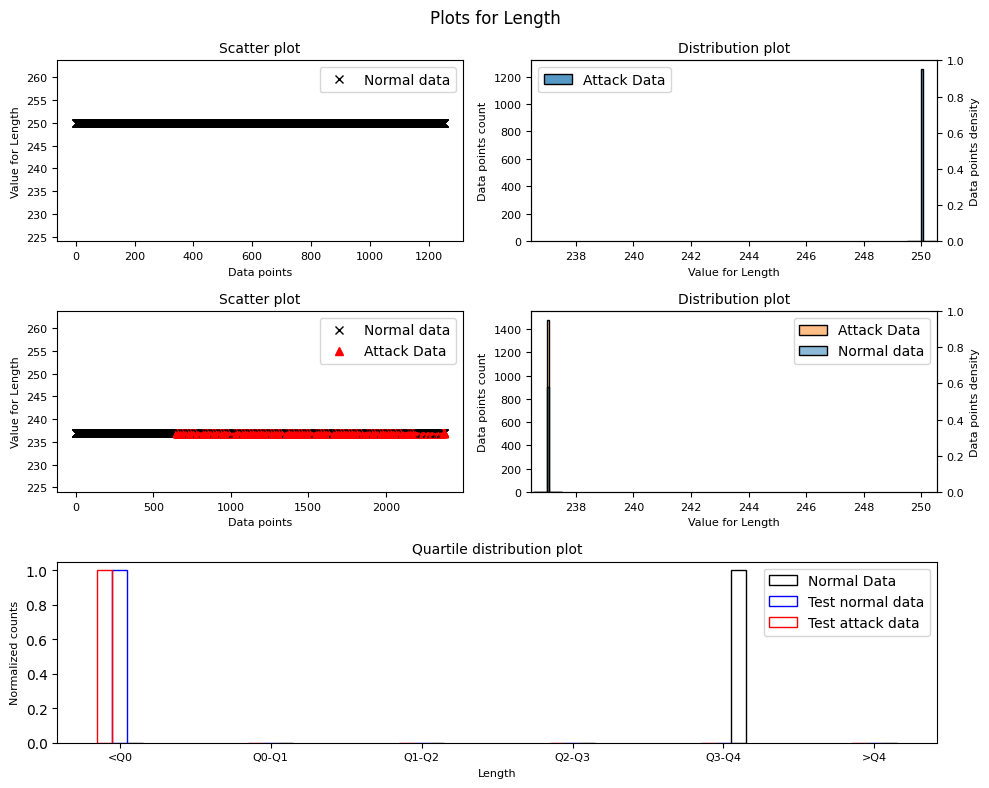

In [22]:
NormalDataFile = normal_new.copy()
TestDataFile = attack_new.copy()
# Filter normal and attack points from the DataFrame
TestData_NormalPts = TestDataFile[TestDataFile['Label']== 0]
TestData_AttackPts = TestDataFile[TestDataFile['Label']!= 0]

# Extract feature values as numpy arrays for a specific feature
FeatureName = 'Length'  

NormalDataFeatureValue = NormalDataFile[FeatureName].to_numpy()
TestDataFeatureValue = TestDataFile[FeatureName].to_numpy()
TestData_NormalPts_FeatureValue = TestData_NormalPts[FeatureName].to_numpy()
TestData_AttackPts_FeatureValue = TestData_AttackPts[FeatureName].to_numpy()

# Extract labels as a numpy array
TestDataLabels = TestDataFile['Label'].to_numpy()

getPlots(NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts_FeatureValue, TestData_AttackPts_FeatureValue, TestDataLabels)

[0.009505  0.0207825 0.16062   1.280624  2.001836 ]


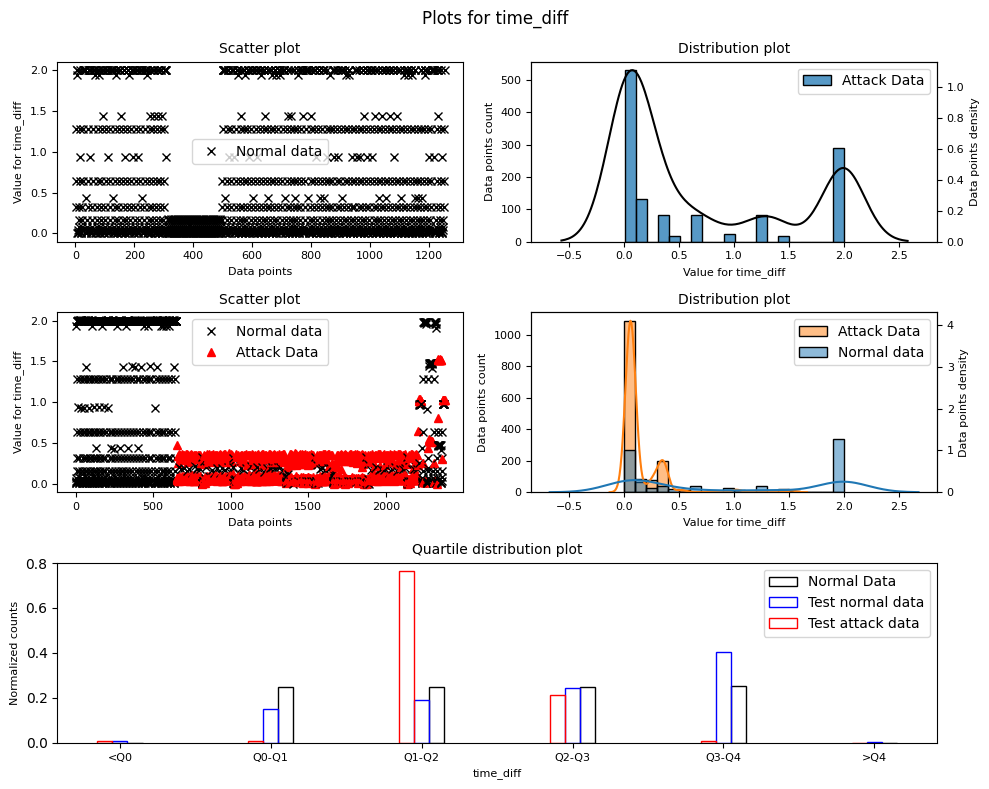

In [23]:
NormalDataFile = normal_new.copy()
TestDataFile = attack_new.copy()
# Filter normal and attack points from the DataFrame
TestData_NormalPts = TestDataFile[TestDataFile['Label']== 0]
TestData_AttackPts = TestDataFile[TestDataFile['Label']!= 0]

# Extract feature values as numpy arrays for a specific feature
FeatureName = 'time_diff'  
#FeatureName = 'bit-string'

NormalDataFeatureValue = NormalDataFile[FeatureName].to_numpy()
TestDataFeatureValue = TestDataFile[FeatureName].to_numpy()
TestData_NormalPts_FeatureValue = TestData_NormalPts[FeatureName].to_numpy()
TestData_AttackPts_FeatureValue = TestData_AttackPts[FeatureName].to_numpy()

# Extract labels as a numpy array
TestDataLabels = TestDataFile['Label'].to_numpy()

getPlots(NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts_FeatureValue, TestData_AttackPts_FeatureValue, TestDataLabels)

[450.  472.  507.  531.5 556. ]


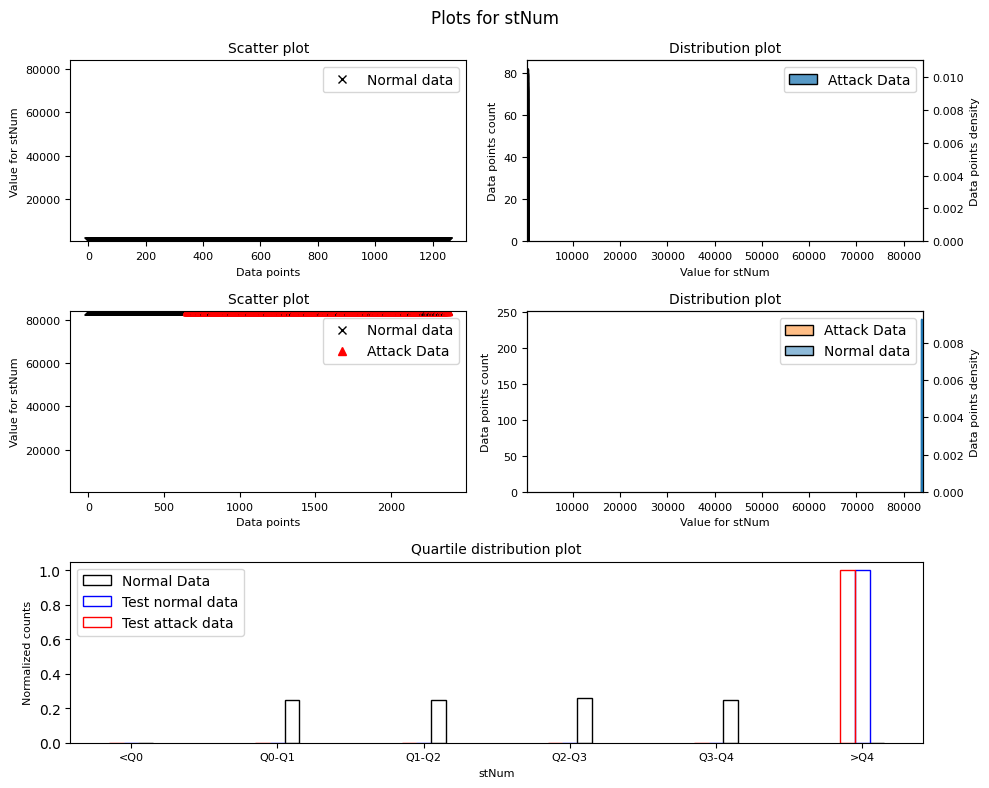

In [24]:
NormalDataFile = normal_new.copy()
TestDataFile = attack_new.copy()
# Filter normal and attack points from the DataFrame
TestData_NormalPts = TestDataFile[TestDataFile['Label']== 0]
TestData_AttackPts = TestDataFile[TestDataFile['Label']!= 0]

# Extract feature values as numpy arrays for a specific feature
FeatureName = 'stNum'  

NormalDataFeatureValue = NormalDataFile[FeatureName].to_numpy()
TestDataFeatureValue = TestDataFile[FeatureName].to_numpy()
TestData_NormalPts_FeatureValue = TestData_NormalPts[FeatureName].to_numpy()
TestData_AttackPts_FeatureValue = TestData_AttackPts[FeatureName].to_numpy()

# Extract labels as a numpy array
TestDataLabels = TestDataFile['Label'].to_numpy()

getPlots(NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts_FeatureValue, TestData_AttackPts_FeatureValue, TestDataLabels)

[ 0.  2.  5.  9. 18.]


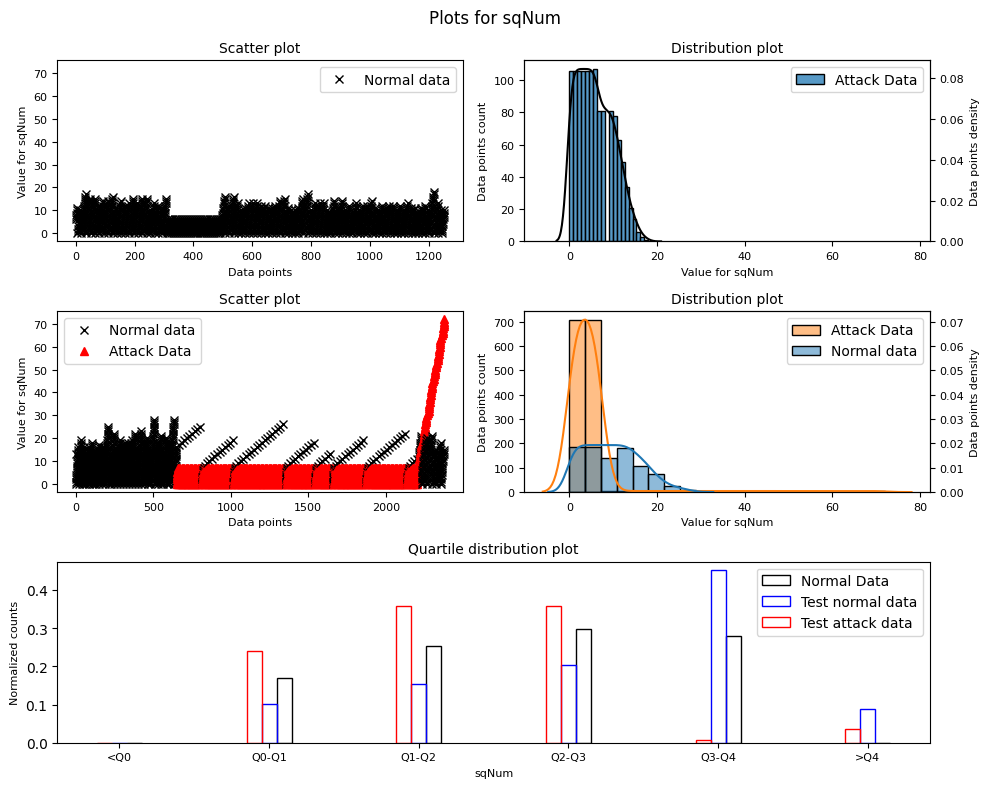

In [25]:
NormalDataFile = normal_new.copy()
TestDataFile = attack_new.copy()
# Filter normal and attack points from the DataFrame
TestData_NormalPts = TestDataFile[TestDataFile['Label']== 0]
TestData_AttackPts = TestDataFile[TestDataFile['Label']!= 0]

# Extract feature values as numpy arrays for a specific feature
FeatureName = 'sqNum'  

NormalDataFeatureValue = NormalDataFile[FeatureName].to_numpy()
TestDataFeatureValue = TestDataFile[FeatureName].to_numpy()
TestData_NormalPts_FeatureValue = TestData_NormalPts[FeatureName].to_numpy()
TestData_AttackPts_FeatureValue = TestData_AttackPts[FeatureName].to_numpy()

# Extract labels as a numpy array
TestDataLabels = TestDataFile['Label'].to_numpy()

getPlots(NormalDataFeatureValue, TestDataFeatureValue, TestData_NormalPts_FeatureValue, TestData_AttackPts_FeatureValue, TestDataLabels)

In [26]:
def getScore(FeatureValue, Mean, Min, Max, Std):
   try:
       # Convert value to numeric if it's not already
       FeatureValue = pd.to_numeric(FeatureValue, errors='coerce')
    
       if FeatureValue < Min or FeatureValue > Max: #  x < 1376
           Score = 5

       elif (Mean-Std <=FeatureValue< Mean+Std):  # 1411 < 1376 < 1507
           Score = 1
        
       elif (Mean-2*Std <=FeatureValue< Mean+2*Std):  # 1362 < 1376 < 1556
           Score = 2
        
       elif (Mean-3*Std <=FeatureValue< Mean+3*Std): # 1314 < x < 1604
           Score = 3             

       else:
           Score = 4

       return(Score)

   except Exception as e:
        print(f"Error processing value {FeatureValue}: {e}")
        return np.nan  # Return NaN or a default score

In [27]:
print(normal_new.columns)
print(attack_new.columns)


Index(['Unnamed: 0', 'Time', 'Time_diff', 'Source', 'Destination', 'Protocol',
       'APPID', 'gocbRef', 'goID', 'Length', 'timeAllowedtoLive', 'datSet',
       't', 'unix_timediff', 'stNum', 'sqNum', 'simulation', 'confRev',
       'ndsCom', 'numDatSetEntries', 'Label', 'label_multi', 'float_value0',
       'float_value1', 'float_value2', 'float_value3', 'float_value4',
       'float_value5', 'bit-string_0', 'bit-string_1', 'bit-string_2',
       'bit-string_3', 'bit-string_4', 'bit-string_5', 'color', 'time_diff'],
      dtype='object')
Index(['Time', 'Time_diff', 'APPID', 'Length', 'timeAllowedtoLive', 't',
       'unix_timediff', 'stNum', 'sqNum', 'simulation', 'confRev', 'ndsCom',
       'numDatSetEntries', 'Label', 'label_multi', 'float_value0',
       'float_value1', 'float_value2', 'float_value3', 'float_value4',
       'float_value5', 'bit-string_0', 'bit-string_1', 'bit-string_2',
       'bit-string_3', 'bit-string_4', 'bit-string_5', 'time_diff'],
      dtype='object')


In [28]:
normal_new = normal_new.drop(['Unnamed: 0', 'Source', 'Destination', 'Protocol', 'gocbRef', 'goID', 'datSet', 'color'], axis = 1)
#normal_new = normal_new.drop(['Source','Destination','Protocol','allData','gocbRef','t','datSet','ndsCom','integer','float value','boolean','Padding','bit-string','goID','Data','Info','confRev','timeAllowedtoLive','numDatSetEntries'], axis = 1)

In [29]:
# Iterate over each column and calculate the score
for column in normal_new.columns:
    score_list = []  # List to hold scores
     # Calculate min, mean, and standard deviation for the column
    Mean = normal_new[column].mean()
    Min = normal_new[column].min()
    Max = normal_new[column].max()
    Std = normal_new[column].std()

    print(Mean, Min, Std, Max)

    for value in attack_new[column]:
        # score_list = []  # List to hold scores
        score = getScore(value,Mean,Min,Max,Std)  # Apply the score calculation function
        score_list.append(score)  # Append the score to the list
    attack_new[f'{column}_Score'] = score_list  # Add a new column with the score

426.69546635856574 0.0 235.22916775209373 853.242004
0.6804162711323763 0.0095049999999901 0.8046041154594784 2.0018360000000257
2.0 2 0.0 2
250.0 250 0.0 250
3000.0 3000 0.0 3000
1649675892.5672953 1649675467.641 235.42851160547883 1649676316.641
0.6770334928229665 0.0 2.746062778923444 21.5
504.1171314741036 450 31.947047766319482 556
5.854980079681275 0 4.052251070164276 18
0.0 False 0.0 False
170001.0 170001 0.0 170001
0.0 False 0.0 False
12.0 12 0.0 12
0.0 0 0.0 0
nan nan nan nan
402.44480239043827 401.233 0.4192919384621537 403.337
401.73080956175295 400.625 0.41363866136188815 402.634
401.7197426294821 400.644 0.4483081859177503 402.728
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0
0.6804162711323763 0.009504999999990105 0.8046041154594784 2.0018360000000257


In [31]:
attack_new.head()

,Time,Time_diff,APPID,Length,timeAllowedtoLive,t,unix_timediff,stNum,sqNum,simulation,...,float_value3_Score,float_value4_Score,float_value5_Score,bit-string_0_Score,bit-string_1_Score,bit-string_2_Score,bit-string_3_Score,bit-string_4_Score,bit-string_5_Score,time_diff_Score
0,1.359248,NaN,2,237,3000,1.659709e+09,NaN,83793,13,False,...,4,4,4,4,4,4,4,4,4,4
1,3.298255,1.939007,2,237,3000,1.659709e+09,12.5,83794,0,False,...,4,4,4,4,4,4,4,4,4,2
2,3.309263,0.011008,2,237,3000,1.659709e+09,0.0,83794,1,False,...,4,4,4,4,4,4,4,4,4,1
3,3.319262,0.009999,2,237,3000,1.659709e+09,0.0,83794,2,False,...,4,4,4,4,4,4,4,4,4,1
4,3.339512,0.020250,2,237,3000,1.659709e+09,0.0,83794,3,False,...,4,4,4,4,4,4,4,4,4,1


In [32]:
attack_new['Length'].value_counts()

Length
237    2380
Name: count, dtype: int64

In [33]:
#Calculating the maximum of the three features
count_final = []
for i in range(len(attack_new)):
    score_final = max(attack_new.iloc[i]['sqNum_Score'], attack_new.iloc[i]['stNum_Score'],attack_new.iloc[i]['Length_Score'],attack_new.iloc[i]['time_diff_Score'])
    count_final.append(score_final)

attack_new['Max_Score'] = count_final
attack_new.head()

,Time,Time_diff,APPID,Length,timeAllowedtoLive,t,unix_timediff,stNum,sqNum,simulation,...,float_value4_Score,float_value5_Score,bit-string_0_Score,bit-string_1_Score,bit-string_2_Score,bit-string_3_Score,bit-string_4_Score,bit-string_5_Score,time_diff_Score,Max_Score
0,1.359248,NaN,2,237,3000,1.659709e+09,NaN,83793,13,False,...,4,4,4,4,4,4,4,4,4,5
1,3.298255,1.939007,2,237,3000,1.659709e+09,12.5,83794,0,False,...,4,4,4,4,4,4,4,4,2,5
2,3.309263,0.011008,2,237,3000,1.659709e+09,0.0,83794,1,False,...,4,4,4,4,4,4,4,4,1,5
3,3.319262,0.009999,2,237,3000,1.659709e+09,0.0,83794,2,False,...,4,4,4,4,4,4,4,4,1,5
4,3.339512,0.020250,2,237,3000,1.659709e+09,0.0,83794,3,False,...,4,4,4,4,4,4,4,4,1,5


In [34]:
# Predicted Value, where the score greator than 3 is considered an anomaly
attack_new['Max_Score_Pred'] = attack_new['Max_Score'].apply(lambda x: 1 if x > 3 else 0)
attack_new.head()

,Time,Time_diff,APPID,Length,timeAllowedtoLive,t,unix_timediff,stNum,sqNum,simulation,...,float_value5_Score,bit-string_0_Score,bit-string_1_Score,bit-string_2_Score,bit-string_3_Score,bit-string_4_Score,bit-string_5_Score,time_diff_Score,Max_Score,Max_Score_Pred
0,1.359248,NaN,2,237,3000,1.659709e+09,NaN,83793,13,False,...,4,4,4,4,4,4,4,4,5,1
1,3.298255,1.939007,2,237,3000,1.659709e+09,12.5,83794,0,False,...,4,4,4,4,4,4,4,2,5,1
2,3.309263,0.011008,2,237,3000,1.659709e+09,0.0,83794,1,False,...,4,4,4,4,4,4,4,1,5,1
3,3.319262,0.009999,2,237,3000,1.659709e+09,0.0,83794,2,False,...,4,4,4,4,4,4,4,1,5,1
4,3.339512,0.020250,2,237,3000,1.659709e+09,0.0,83794,3,False,...,4,4,4,4,4,4,4,1,5,1


In [35]:
attack_new.dtypes

Time                       float64
Time_diff                  float64
APPID                        int64
Length                       int64
timeAllowedtoLive            int64
t                          float64
unix_timediff              float64
stNum                        int64
sqNum                        int64
simulation                    bool
confRev                      int64
ndsCom                        bool
numDatSetEntries             int64
Label                        int64
label_multi                  int64
float_value0               float64
float_value1               float64
float_value2               float64
float_value3               float64
float_value4               float64
float_value5               float64
bit-string_0               float64
bit-string_1               float64
bit-string_2               float64
bit-string_3               float64
bit-string_4               float64
bit-string_5               float64
time_diff                  float64
Time_Score          

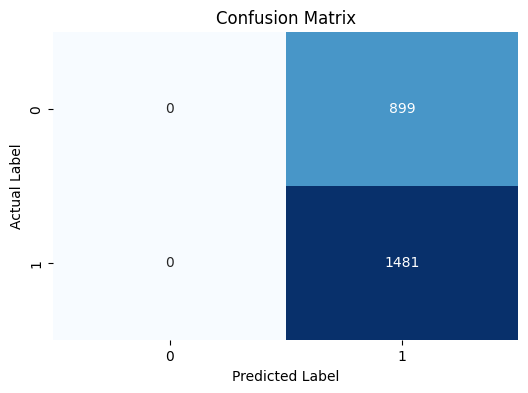

In [36]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, classification_report,accuracy_score

conf_matrix = confusion_matrix(attack_new['Label'], attack_new['Max_Score_Pred'])

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

In [37]:
print("Accuracy Score :")
print(accuracy_score(attack_new['Label'], attack_new['Max_Score_Pred']))
print("Classification Report :")
print(classification_report(attack_new['Label'], attack_new['Max_Score_Pred']))

Accuracy Score :
0.6222689075630252
Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       899
           1       0.62      1.00      0.77      1481

    accuracy                           0.62      2380
   macro avg       0.31      0.50      0.38      2380
weighted avg       0.39      0.62      0.48      2380



/home/pruthvish/NFSU/Odd_25_26/Python_Scripting/VirtualEnv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pruthvish/NFSU/Odd_25_26/Python_Scripting/VirtualEnv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pruthvish/NFSU/Odd_25_26/Python_Scripting/VirtualEnv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

In [38]:
attack_new

,Time,Time_diff,APPID,Length,timeAllowedtoLive,t,unix_timediff,stNum,sqNum,simulation,...,float_value5_Score,bit-string_0_Score,bit-string_1_Score,bit-string_2_Score,bit-string_3_Score,bit-string_4_Score,bit-string_5_Score,time_diff_Score,Max_Score,Max_Score_Pred
0,1.359248,NaN,2,237,3000,1.659709e+09,NaN,83793,13,False,...,4,4,4,4,4,4,4,4,5,1
1,3.298255,1.939007,2,237,3000,1.659709e+09,12.500000,83794,0,False,...,4,4,4,4,4,4,4,2,5,1
2,3.309263,0.011008,2,237,3000,1.659709e+09,0.000000,83794,1,False,...,4,4,4,4,4,4,4,1,5,1
3,3.319262,0.009999,2,237,3000,1.659709e+09,0.000000,83794,2,False,...,4,4,4,4,4,4,4,1,5,1
4,3.339512,0.020250,2,237,3000,1.659709e+09,0.000000,83794,3,False,...,4,4,4,4,4,4,4,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2375,1053.384326,1.023289,2,237,3000,1.659710e+09,44.314999,84004,70,False,...,4,4,4,4,4,4,4,1,5,1
2376,1054.361398,0.977072,2,237,3000,1.659710e+09,-44.314999,83839,14,False,...,4,4,4,4,4,4,4,1,5,1
2377,1055.384144,1.022746,2,237,3000,1.659710e+09,44.314999,84004,71,False,...,4,4,4,4,4,4,4,1,5,1
2378,1056.361170,0.977026,2,237,3000,1.659710e+09,-44.314999,83839,15,False,...,4,4,4,4,4,4,4,1,5,1


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


In [40]:
# 1. Separate features and target from attack_new
X = attack_new.drop(columns=['Label'])
y = attack_new['Label']

# 2. Split data into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Scale training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Scale testing features using training parameters
X_test_scaled = scaler.transform(X_test)

# 5. Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 6. Run inference on test data
predictions = rf.predict(X_test_scaled)


In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


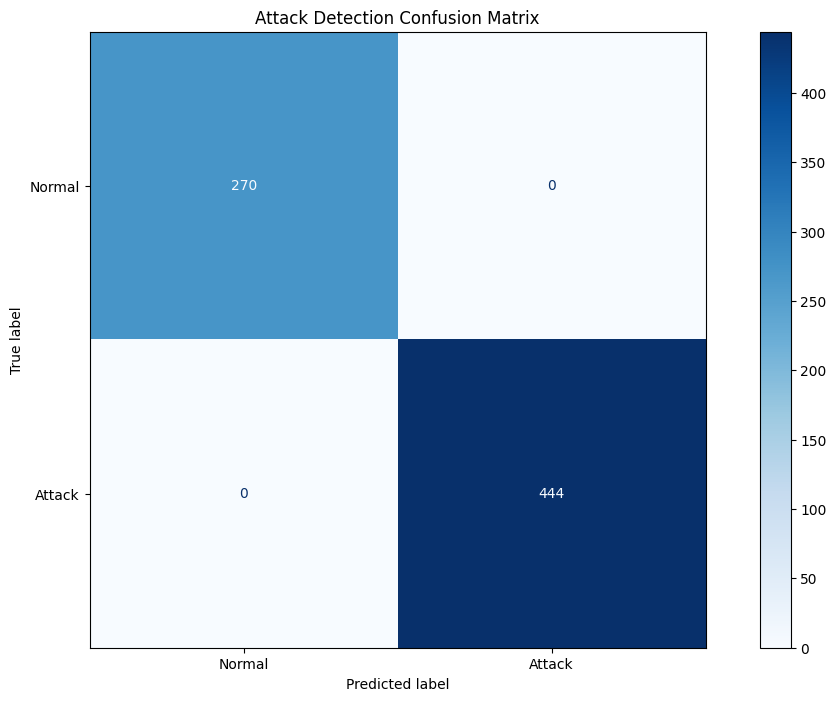

In [43]:
# 1. Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

# 2. Setup display labels matching your data (0: Normal, 1: Attack)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])

# 3. Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Attack Detection Confusion Matrix')
plt.show()


In [45]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

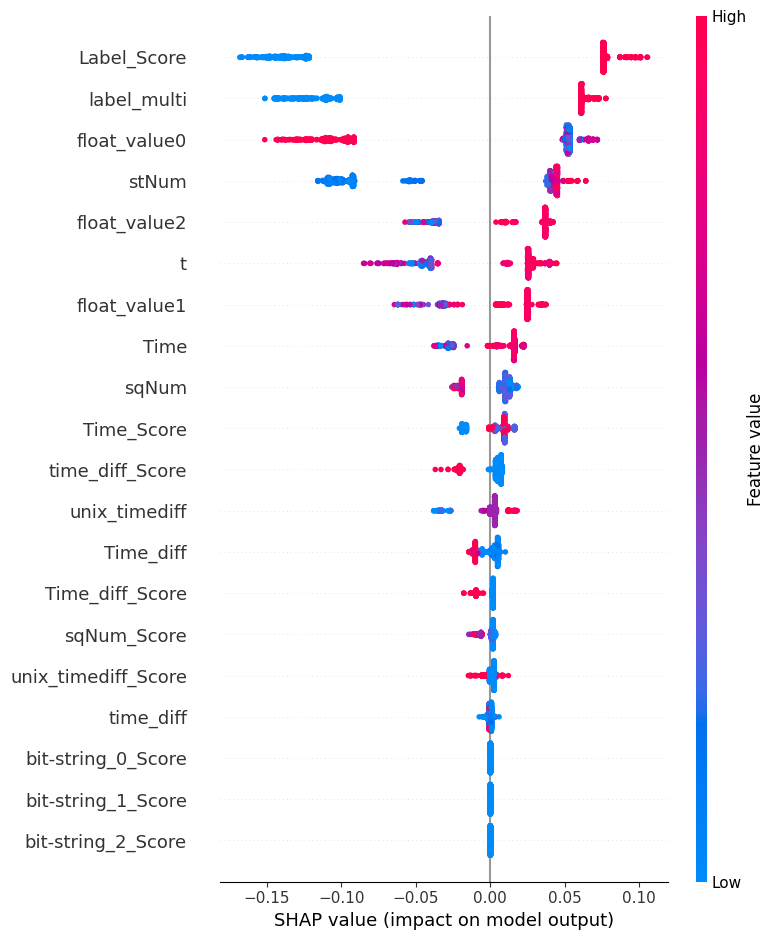

In [47]:
# The modern, error-free way in newer SHAP versions:
explainer = shap.TreeExplainer(rf)

# Pass the scaled array directly to the explainer object
shap_values_obj = explainer(X_test_scaled)

# Pull out the slice for the Attack class (index 1)
shap.summary_plot(shap_values_obj[:, :, 1], feature_names=feature_names)
